# Root Finding II: Newton's Method

**Contents:** 1. the idea: tangent lines · 2. Newton's method in Python · 3. quadratic convergence · 4. what can go wrong · 5. multiple roots · 6. safeguarded Newton · 7. Newton without derivatives · 8. when to stop · 9. summary · **Activity** (2 problems)

We use `numpy` for the numerical methods, `sympy` for exact derivatives and reference roots, and `matplotlib` for the plots. This notebook goes with the slides *Root Finding II: Newton's Method*.

In [41]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

print("sympy", sp.__version__, "| numpy", np.__version__)

sympy 1.14.0 | numpy 2.5.2


---
## 1. The idea: follow the tangent line

Bracketing methods only need a sign change, but they converge **linearly**. Newton's method also uses the **derivative** $f'(x)$. Near the current guess $x_n$, replace $f$ by its **tangent line**

$$\ell(x) = f(x_n) + f'(x_n)\,(x - x_n),$$

and take the zero of $\ell$ as the next guess:

$$\boxed{\,x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}\,}$$

The same formula comes from Taylor's theorem: $f(x) = f(x_n) + f'(x_n)(x - x_n) + \tfrac12 f''(\xi)(x - x_n)^2$. Dropping the quadratic term leaves the tangent line, and the neglected term is $O\big((x - x_n)^2\big)$, which is why the method is so fast once $x_n$ is close to the root.

| | false position | Newton |
|---|---|---|
| model of $f$ | **secant** line through two bracket points | **tangent** line at one point |
| needs | a bracket $[a, b]$ | a starting guess $x_0$ and $f'$ |
| keeps a bracket | yes | **no** |

The cell below draws the first two Newton steps for $f(x) = x^2 - 2$ from $x_0 = 1$.

x_1 = 1.5000000000,  error = 8.6e-02
x_2 = 1.4166666667,  error = 2.5e-03


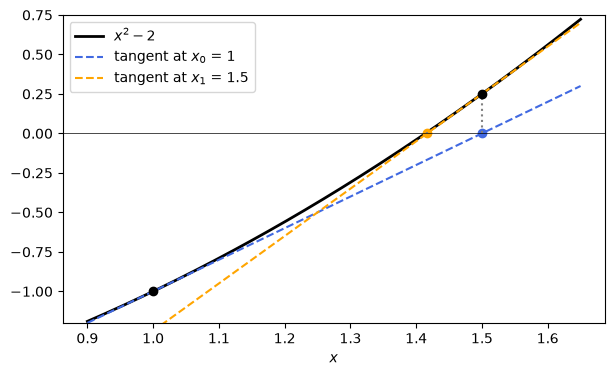

In [42]:
def f_sq(t):
    return t**2 - 2

def df_sq(t):
    return 2 * t

xs = np.linspace(0.9, 1.65, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, f_sq(xs), "k", lw=2, label="$x^2 - 2$")
xn = 1.0
for n, color in [(0, "royalblue"), (1, "orange")]:
    x_next = xn - f_sq(xn) / df_sq(xn)
    ax.plot(xs, f_sq(xn) + df_sq(xn) * (xs - xn), "--", color=color, label=f"tangent at $x_{n}$ = {xn:.4g}")
    ax.plot([xn], [f_sq(xn)], "o", color="k")
    ax.plot([x_next], [0], "o", color=color)
    ax.vlines(x_next, 0, f_sq(x_next), color="gray", ls=":")
    print(f"x_{n + 1} = {x_next:.10f},  error = {abs(x_next - np.sqrt(2)):.1e}")
    xn = x_next
ax.axhline(0, color="k", lw=0.5)
ax.set_ylim(-1.2, 0.75); ax.set_xlabel("$x$"); ax.legend(loc="upper left")
plt.show()

---
## 2. Newton's method in Python

The function returns the list `hist` of all iterates $x_1, x_2, \ldots$, and it stops if it lands **exactly** on a root.

**Details in the code below:**
- **Two evaluations per step:** one of $f$ and one of $f'$.
- **`if fx == 0`:** in bisection we did not need this test. Here we do: at a double root both $f$ and $f'$ vanish, and the step $0/0$ would stop the method with an error even though $x$ is the root (Section 5).
- **`if dfx == 0`:** a horizontal tangent never crosses the axis, so the step is undefined.
- **Raise, don't return:** bisection always returns a good answer. Newton **may not converge**, so reaching `maxit` is an **error**, not a result.
- **Step-size test** $|x_{n+1} - x_n| < \text{tol}$: there is no bracket, so there is no error bound; Section 8 shows why the step is a good error estimate for Newton.

In [43]:
def newton(f, df, x0, tol=1e-12, maxit=50):
    x = x0
    hist = []
    for n in range(maxit):
        fx, dfx = f(x), df(x)        # two evaluations per step
        if np.abs(fx) < 1e-12:                  # landed very close to a root
            return x, hist
        if np.abs(dfx) < 1e-12:         # derivative is effectively zero
            raise ZeroDivisionError(f"f'(x) = 0 at x = {x}: the tangent is horizontal")
        dx = fx / dfx                # Newton step
        x = x - dx
        hist.append(x)
        if abs(dx) < tol:            # step-size test
            return x, hist
    raise RuntimeError(f"no convergence in {maxit} steps (last x = {x})")

x_star, hist = newton(f_sq, df_sq, 1.0)
e = [abs(xn - np.sqrt(2)) for xn in hist]
print(f"{'n':>3} {'x_n':>20} {'|x_n - sqrt2|':>14} {'e_n / e_(n-1)^2':>16}")
for n in range(len(hist)):
    ratio = f"{e[n] / e[n - 1]**2:16.3f}" if 0 < n and e[n] > 0 and e[n - 1] > 1e-15 else ""
    print(f"{n + 1:>3} {hist[n]:20.16f} {e[n]:14.2e} {ratio}")
print(f"\n1/(2 sqrt2) = {1 / (2 * np.sqrt(2)):.3f}")

  n                  x_n  |x_n - sqrt2|  e_n / e_(n-1)^2
  1   1.5000000000000000       8.58e-02 
  2   1.4166666666666667       2.45e-03            0.333
  3   1.4142156862745099       2.12e-06            0.353
  4   1.4142135623746899       1.59e-12            0.354
  5   1.4142135623730951       0.00e+00 

1/(2 sqrt2) = 0.354


The number of correct digits goes $2, 6, 12, 16$: it **doubles** every step until machine precision. The ratio $e_n / e_{n-1}^2$ settles to a constant; Section 3 explains where $1/(2\sqrt2) \approx 0.354$ comes from.

**Getting $f'$ with SymPy.** Writing $f'$ by hand is error-prone. SymPy differentiates the expression exactly with `sp.diff`, and `sp.lambdify` turns both expressions into NumPy functions that `newton` can use.

In [44]:
x = sp.Symbol('x', real=True)
expr = sp.cos(x) - x
dexpr = sp.diff(expr, x)
display(Math(r"f(x) = " + sp.latex(expr) + r", \qquad f'(x) = " + sp.latex(dexpr)))

f_cos = sp.lambdify(x, expr, 'numpy')
df_cos = sp.lambdify(x, dexpr, 'numpy')
r_cos, hist = newton(f_cos, df_cos, 1.0)
print(f"root of cos x - x: {r_cos:.15f}  after {len(hist)} steps")

<IPython.core.display.Math object>

root of cos x - x: 0.739085133215161  after 4 steps


---
## 3. Quadratic convergence

Let $e_n = x_n - r$. Taylor's theorem around $x_n$, evaluated at the root, gives

$$0 = f(r) = f(x_n) - f'(x_n)\,e_n + \tfrac12 f''(\xi_n)\,e_n^2 .$$

Divide by $f'(x_n)$ and use the Newton formula:

$$e_{n+1} = \frac{f''(\xi_n)}{2f'(x_n)}\,e_n^2 \qquad\Longrightarrow\qquad e_{n+1} \approx C\,e_n^2, \quad C = \frac{f''(r)}{2f'(r)}.$$

For $x^2 - 2$: $f'' = 2$ and $f'(\sqrt2) = 2\sqrt2$, so $C = 1/(2\sqrt2)$: exactly the ratio in the table of Section 2.

| order $p$ in $\lvert e_{n+1}\rvert \approx C\,\lvert e_n\rvert^p$ | method |
|---|---|
| $p = 1$ (linear) | bisection, false position |
| $p \approx 1.618$ | secant (Section 7) |
| $p = 2$ (quadratic) | Newton |

**Theorem (local convergence).** If $f$ is twice continuously differentiable near $r$, $f(r) = 0$ and $f'(r) \neq 0$, there is a $\delta > 0$ such that Newton converges quadratically for every $x_0$ with $|x_0 - r| < \delta$. The theorem does **not** say how small $\delta$ is: Newton is a **local** method.

To compare with the bracketing methods we copy `bisection` and `false_position` from the previous notebook (unchanged). On a `semilogy` plot, linear convergence is a straight line; Newton's curve **bends down**.

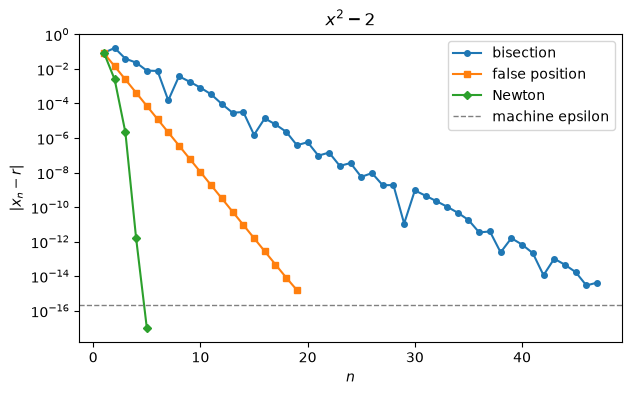

In [45]:
def bisection(f, a, b, tol=1e-12, maxit=200):
    fa = f(a)
    if np.sign(fa) == np.sign(f(b)):
        raise ValueError("[a, b] is not a bracket: f(a) and f(b) have the same sign")
    hist = []
    for n in range(maxit):
        c = a + (b - a) / 2
        fc = f(c)
        hist.append(c)
        if (b - a) / 2 < tol:
            break
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc
        else:
            b = c
    return c, hist

def false_position(f, a, b, tol=1e-12, maxit=200):
    fa, fb = f(a), f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("[a, b] is not a bracket: f(a) and f(b) have the same sign")
    hist = []
    c_old = np.inf
    for n in range(maxit):
        c = b - fb * (b - a) / (fb - fa)
        fc = f(c)
        hist.append(c)
        if abs(c - c_old) < tol:
            break
        c_old = c
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc
        else:
            b, fb = c, fc
    return c, hist

runs = [("bisection", bisection(f_sq, 1, 2, tol=1e-14)[1], "o-"),
        ("false position", false_position(f_sq, 1, 2, tol=1e-14)[1], "s-"),
        ("Newton", newton(f_sq, df_sq, 1.0, tol=1e-14)[1], "D-")]

fig, ax = plt.subplots(figsize=(7, 4))
for name, hist, style in runs:
    err = np.maximum(np.abs(np.array(hist) - np.sqrt(2)), 1e-17)     # avoid log(0)
    ax.semilogy(np.arange(1, len(err) + 1), err, style, ms=4, label=name)
ax.axhline(np.finfo(float).eps, color="gray", ls="--", lw=1, label="machine epsilon")
ax.set_title("$x^2 - 2$"); ax.set_xlabel("$n$"); ax.set_ylabel(r"$|x_n - r|$"); ax.legend()
plt.show()

---
## 4. What can go wrong

Newton only uses **local** information. Far from the root the tangent can point anywhere.

| example | $x_0$ | what happens |
|---|---|---|
| $x^{10} - 1$ | $0.5$ | **overshoot**: $f'(x_0) \approx 0.02$, so the first step jumps to $x_1 \approx 51.6$; dozens of steps to crawl back |
| $x^3 - 2x + 2$ | $0$ | **cycling**: $0, 1, 0, 1, \ldots$ forever; the real root $r \approx -1.769$ is never reached |
| $\arctan x$ | $1.5$ | **divergence**: each step overshoots more; from $x_0 = 1.3$ it converges to $0$ |

To **watch** a run that may not converge, `newton` is not useful: it raises an error and we lose the iterates. The helper `newton_steps` below just takes a fixed number of steps, with no stopping test.

In [46]:
def newton_steps(f, df, x0, nsteps):
    # Return [x_1, ..., x_nsteps] without any stopping test.
    xs = []
    xn = x0
    for n in range(nsteps):
        xn = xn - f(xn) / df(xn)
        xs.append(xn)
    return xs

def f_ten(t):
    return t**10 - 1

def df_ten(t):
    return 10 * t**9

def f_cyc(t):
    return t**3 - 2 * t + 2

def df_cyc(t):
    return 3 * t**2 - 2

def df_atan(t):
    return 1 / (1 + t**2)

x_star, hist = newton(f_ten, df_ten, 0.5)
print(f"x^10 - 1,   x0 = 0.5: x1 = {hist[0]:.2f}, converged to {x_star} after {len(hist)} steps")
print("x^3-2x+2,   x0 = 0  :", newton_steps(f_cyc, df_cyc, 0.0, 6))
print("arctan x,   x0 = 1.5:", [round(float(v), 2) for v in newton_steps(np.arctan, df_atan, 1.5, 6)])
print("arctan x,   x0 = 1.3:", [round(float(v), 6) for v in newton_steps(np.arctan, df_atan, 1.3, 6)])

try:
    newton(f_cyc, df_cyc, 0.0, maxit=30)
except RuntimeError as err:
    print("\nnewton on x^3 - 2x + 2 from x0 = 0 ->", err)

x^10 - 1,   x0 = 0.5: x1 = 51.65, converged to 1.0 after 43 steps
x^3-2x+2,   x0 = 0  : [1.0, 0.0, 1.0, 0.0, 1.0, 0.0]
arctan x,   x0 = 1.5: [-1.69, 2.32, -5.11, 32.3, -1575.32, 3894976.01]
arctan x,   x0 = 1.3: [-1.161621, 0.858896, -0.374241, 0.034019, -2.6e-05, 0.0]

newton on x^3 - 2x + 2 from x0 = 0 -> no convergence in 30 steps (last x = 0.0)


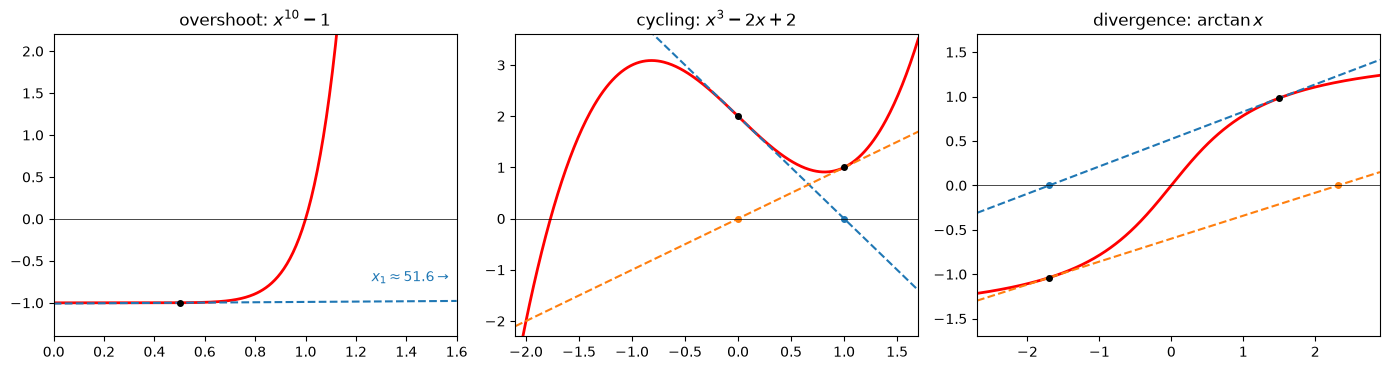

In [47]:
cases = [("overshoot: $x^{10} - 1$", f_ten, df_ten, 0.5, 1, (0, 1.6), (-1.4, 2.2)),
         ("cycling: $x^3 - 2x + 2$", f_cyc, df_cyc, 0.0, 2, (-2.1, 1.7), (-2.3, 3.6)),
         (r"divergence: $\arctan x$", np.arctan, df_atan, 1.5, 2, (-2.7, 2.9), (-1.7, 1.7))]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (title, f, df, x0, nsteps, xlim, ylim) in zip(axes, cases):
    xs = np.linspace(*xlim, 400)
    ax.plot(xs, f(xs), "r", lw=2)
    xn = x0
    for n in range(nsteps):
        ax.plot(xs, f(xn) + df(xn) * (xs - xn), "--", color=f"C{n}")
        ax.plot([xn], [f(xn)], "ko", ms=4)
        xn = xn - f(xn) / df(xn)
        ax.plot([xn], [0], "o", color=f"C{n}", ms=4)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_title(title)
axes[0].annotate(r"$x_1 \approx 51.6 \rightarrow$", xy=(1.58, -0.75), ha="right", color="C0")
plt.tight_layout()
plt.show()

---
## 5. Multiple roots: Newton slows down to linear

$f(x) = (x - 1)^2 (x + 1)$ has a **double root** at $r = 1$: $f(1) = f'(1) = 0$. It touches the axis without a sign change, so no bracket exists. Newton still converges, but the theorem of Section 3 does not apply ($f'(r) = 0$).

If $f(x) = (x - r)^m h(x)$ with $h(r) \neq 0$ (a root of **multiplicity** $m$), then

$$e_{n+1} \approx \Big(1 - \frac1m\Big)\,e_n :$$

linear, with $\rho = 1 - \tfrac1m$ ($\rho = \tfrac12$ for a double root, no better than bisection). If $m$ is known, the **modified Newton** step

$$x_{n+1} = x_n - m\,\frac{f(x_n)}{f'(x_n)}$$

is quadratic again. We get it from `newton` without changing the code: pass $f'/m$ instead of $f'$.

In [48]:
def f_dbl(t):
    return (t - 1)**2 * (t + 1)

def df_dbl(t):
    return 2 * (t - 1) * (t + 1) + (t - 1)**2

def df_dbl_over_2(t):              # f'/m with m = 2: newton then takes the modified step
    return df_dbl(t) / 2

x_star, hist = newton(f_dbl, df_dbl, 2.0, maxit=100)
e = [abs(v - 1) for v in hist]
print(f"Newton         : {len(hist)} steps, ratios e_n/e_(n-1) =", [round(e[n] / e[n - 1], 3) for n in range(1, 7)])

x_star, hist = newton(f_dbl, df_dbl_over_2, 2.0)
print(f"modified Newton: {len(hist)} steps, errors =", [f"{abs(v - 1):.1e}" for v in hist])

Newton         : 21 steps, ratios e_n/e_(n-1) = [0.55, 0.532, 0.519, 0.51, 0.505, 0.503]
modified Newton: 4 steps, errors = ['1.4e-01', '4.6e-03', '5.3e-06', '7.0e-12']


---
## 6. Safeguarded Newton: Newton with a bracket

Bracketing methods are reliable; Newton is fast. **Safeguarded Newton** keeps both:

1. keep a bracket $[a, b]$ at all times, updated with the sign of $f(x)$ exactly as in bisection;
2. take the Newton step if it lands **inside** $[a, b]$;
3. otherwise (or if $f'(x) = 0$) take a **bisection** step.

It is **guaranteed** to converge, like bisection, and near the root Newton steps always land inside, so it is **quadratic**. The function is the one from the slides, with the list `hist` added.

In [49]:
def safe_newton(f, df, a, b, tol=1e-12, maxit=100):
    fa = f(a)
    if np.sign(fa) == np.sign(f(b)):
        raise ValueError("[a, b] is not a bracket: f(a) and f(b) have the same sign")
    x = a + (b - a) / 2
    hist = []
    for n in range(maxit):
        fx, dfx = f(x), df(x)
        if np.sign(fx) == np.sign(fa):
            a, fa = x, fx                  # root in [x, b]
        else:
            b = x                          # root in [a, x]
        if dfx != 0:
            xnew = x - fx / dfx            # try Newton
        if dfx == 0 or not (a <= xnew <= b):
            xnew = a + (b - a) / 2         # fall back to bisection
        hist.append(xnew)
        if abs(xnew - x) < tol:
            return xnew, hist
        x = xnew
    return x, hist

def steps_to(hist, r, tol):
    # first n (counting from 1) with |x_n - r| < tol, or None
    for n in range(len(hist)):
        if abs(hist[n] - r) < tol:
            return n + 1
    return None

results = [("bisection on [0, 1.3]", bisection(f_ten, 0, 1.3, tol=1e-14)[1]),
           ("false position on [0, 1.3]", false_position(f_ten, 0, 1.3, tol=1e-14, maxit=500)[1]),
           ("Newton from x0 = 0.65", newton(f_ten, df_ten, 0.65, tol=1e-14)[1]),
           ("safeguarded Newton on [0, 1.3]", safe_newton(f_ten, df_ten, 0, 1.3, tol=1e-14)[1])]
print("x^10 - 1, steps to reach an error of 1e-6:")
for name, hist in results:
    print(f"  {name:>31}: {steps_to(hist, 1.0, 1e-6)}")
print("\nsafeguarded Newton iterates:", [round(v, 8) for v in results[3][1][:4]])
print("plain Newton from the midpoint 0.65 first jumps to", round(newton_steps(f_ten, df_ten, 0.65, 1)[0], 2))

x^10 - 1, steps to reach an error of 1e-6:
            bisection on [0, 1.3]: 20
       false position on [0, 1.3]: 61
            Newton from x0 = 0.65: 21
   safeguarded Newton on [0, 1.3]: 4

safeguarded Newton iterates: [0.975, 1.00309098, 1.00004251, 1.00000001]
plain Newton from the midpoint 0.65 first jumps to 5.41


The first safeguarded step is a bisection step: the Newton step from $0.65$ would land at $5.4$, outside the bracket $[0.65, 1.3]$. After that, every Newton step lands inside and three steps finish the job.

---
## 7. Newton without derivatives

Newton's idea only needs **a slope** at $x_n$. If $f'$ is unknown or expensive, approximate it.

**Option 1: finite-difference Newton.**

$$f'(x_n) \approx \frac{f(x_n + h) - f(x_n)}{h}, \qquad h \approx \sqrt{\varepsilon_{\text{mach}}}\,|x_n| \approx 10^{-8}|x_n| .$$

Still **two evaluations** per step. If $h$ is too large the slope is inaccurate ($O(h)$ error) and convergence is no longer quadratic; if $h$ is too small, rounding in $f(x_n + h) - f(x_n)$ ruins the slope.

**Option 2: the secant method.** We already know $f(x_{n-1})$, so we can use the slope through the last **two** iterates for free:

$$f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}} \qquad\Longrightarrow\qquad x_{n+1} = x_n - f(x_n)\,\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}.$$

| | finite-difference Newton | secant |
|---|---|---|
| start | $x_0$ | $x_0$, $x_1$ |
| evaluations per step | 2 | **1** |
| order $p$ | $\approx 2$ (if $h \approx 10^{-8}$) | $\frac{1 + \sqrt5}{2} \approx 1.618$ |
| bracket / guarantee | no / no | no / no |

The secant formula is the false position formula, but it always keeps the **two newest** points instead of a bracket. The function `secant` is given in Problem 2 (the same code as on the slides, with the list `hist` added). The cell below tries finite-difference Newton with three choices of $h$; $f'$ is never used.

In [50]:
def fd_newton(f, x0, h, nsteps):
    # Newton with a forward-difference slope; nsteps steps, no stopping test.
    xs = []
    xn = x0
    for n in range(nsteps):
        slope = (f(xn + h) - f(xn)) / h
        xn = xn - f(xn) / slope
        xs.append(xn)
    return xs

hs = [1e-3, 1e-8, 1e-15]
print(f"{'n':>3}" + "".join(f"{'h = ' + format(h, '.0e'):>14}" for h in hs))
runs = [fd_newton(f_sq, 1.0, h, 6) for h in hs]
for n in range(6):
    print(f"{n + 1:>3}" + "".join(f"{abs(run[n] - np.sqrt(2)):14.1e}" for run in runs))

  n     h = 1e-03     h = 1e-08     h = 1e-15
  1       8.6e-02       8.6e-02       3.6e-02
  2       2.5e-03       2.5e-03       2.8e-03
  3       3.0e-06       2.1e-06       2.5e-04
  4       1.1e-09       1.6e-12       2.3e-05
  5       3.8e-13       2.2e-16       2.1e-06
  6       0.0e+00       0.0e+00       1.9e-07


$h = 10^{-8}$ reproduces exact Newton; $h = 10^{-3}$ is still fast but no longer doubles the digits; $h = 10^{-15}$ stalls well above machine precision because the slope is computed from two almost equal numbers.

---
## 8. When do we stop?

Without a bracket there is no guaranteed error bound. But quadratic convergence makes the **step size** a very good error estimate:

$$x_{n+1} - x_n = e_{n+1} - e_n \approx -e_n \quad\text{since } |e_{n+1}| \ll |e_n| .$$

So $|x_{n+1} - x_n| \approx |e_n|$, and the new iterate $x_{n+1}$ is far more accurate than that.

| test | for Newton |
|---|---|
| step size $\lvert x_{n+1} - x_n\rvert < \text{tol}$ (or $\text{tol}\cdot\lvert x_{n+1}\rvert$, relative) | the natural choice: estimates the error of $x_n$ |
| residual $\lvert f(x_n)\rvert$ | a useful **extra** check that we found a root, not just a small step (see Problem 2) |
| maximum number of iterations | **always**; raise an error if it is reached |

The cell below compares the step with the true errors for $x^2 - 2$.

In [51]:
x_star, hist = newton(f_sq, df_sq, 1.0)
xs = [1.0] + hist
print(f"{'n':>3} {'step |x_n - x_(n-1)|':>21} {'error of x_(n-1)':>17} {'error of x_n':>13}")
for n in range(1, 5):
    print(f"{n:>3} {abs(xs[n] - xs[n - 1]):21.2e} {abs(xs[n - 1] - np.sqrt(2)):17.2e} {abs(xs[n] - np.sqrt(2)):13.2e}")

  n  step |x_n - x_(n-1)|  error of x_(n-1)  error of x_n
  1              5.00e-01          4.14e-01      8.58e-02
  2              8.33e-02          8.58e-02      2.45e-03
  3              2.45e-03          2.45e-03      2.12e-06
  4              2.12e-06          2.12e-06      1.59e-12


---
## 9. Summary

| | bisection | false position | Newton | secant |
|---|---|---|---|---|
| needs | bracket | bracket | $x_0$ and $f'$ | $x_0$, $x_1$ |
| always converges | yes | yes | **no** (local) | **no** (local) |
| order $p$ | 1 | 1 | **2** | 1.618 |
| evaluations per step | 1 | 1 | 2 ($f$, $f'$) | 1 |
| order per evaluation | 1 | 1 | $\sqrt2 \approx 1.41$ | **1.618** |
| double roots | no | no | yes, linear | yes, linear |
| natural stopping test | $(b-a)/2 < \text{tol}$ | step size | step size | step size |

**Rule of thumb:** reliability from brackets, speed from Newton; in practice, combine them (safeguarded Newton). Next session: the same methods in `scipy.optimize` (`newton`, `brentq`, `root_scalar`).

---
# Activity

Two problems. **Problem 1** uses SymPy to get exact derivatives, runs Newton on the test problems from the previous notebook, and checks the quadratic convergence constant $C = f''(r)/(2f'(r))$. **Problem 2** gives you the **secant method** as a ready-made function `secant`, and asks you to race it against Newton and safeguarded Newton, counting **function evaluations**. Each step says **what your code should do**. Write the code in the empty cell, then run the **check** cell: it prints your results next to the **expected** ones. Open a **Hint** box only when you are stuck.

**About `None` and `pass`:** replace `None` by your answer, and delete `pass` once you write the body of a function.

**Useful commands for this activity**

| you want to ... | command |
|---|---|
| derivative of an expression $e$ | `sp.diff(e, x)`; second derivative `sp.diff(e, x, 2)` |
| turn an expression into a NumPy function | `sp.lambdify(x, e, 'numpy')` |
| substitute a number into an expression | `e.subs(x, value)`, then `float(...)` |
| add to a list / list of lists | `L = []`, `L.append(v)`; `M[k][j]` is entry `j` of row `k` |
| the methods | `newton(f, df, x0, tol, maxit)`, `safe_newton(f, df, a, b, tol, maxit)`, the given `secant(f, x0, x1, tol, maxit)` (Problem 2): each returns `(x, hist)` |
| steps to reach an error tol | `steps_to(hist, r, tol)` (Section 6) |

---
## Problem 1: Newton with SymPy derivatives

**Goal:** let SymPy compute $f'$ exactly, run `newton` on the four test problems of the previous notebook, and check that the error really behaves like $e_{n+1} \approx C\,e_n^2$.

**What you will see:** Newton needs 4 steps where bisection needed 34, except on $x^{10} - 1$, where a bad first step costs 22 steps. The observed ratios $e_n / e_{n-1}^2$ approach the constant $|f''(r)/(2f'(r))|$ predicted by the theory.

Run the cell below to create the test problems (do not change it). It is the same setup as in the previous notebook: problem number `k` has the name `names[k]`, the expression `exprs[k]`, the bracket `a_list[k]`, `b_list[k]`, the NumPy function `funcs[k]`, and an accurate reference root `r_ref[k]`.

In [52]:
x = sp.Symbol('x', real=True)
names  = ["x^2 - 2", "x^10 - 1", "x^3 - x - 2", "cos x - x"]
exprs  = [x**2 - 2, x**10 - 1, x**3 - x - 2, sp.cos(x) - x]
a_list = [1, 0, 1, 0]
b_list = [2, sp.Rational(13, 10), 2, 1]
funcs = []
r_ref = []
for k in range(len(exprs)):
    funcs.append(sp.lambdify(x, exprs[k], 'numpy'))
    r_ref.append(float(sp.nsolve(exprs[k], x, (a_list[k], b_list[k]), solver='bisect')))
print("reference roots:", r_ref)

reference roots: [1.4142135623730951, 1.0, 1.5213797068045676, 0.7390851332151607]


### Step 1: derivatives with SymPy

Write code that:

1. builds a list `dexprs` with one entry per test problem: entry `k` is the derivative of `exprs[k]` with respect to `x`;
2. builds a list `dfuncs`: entry `k` is `dexprs[k]` turned into a NumPy function with `sp.lambdify`;
3. displays each name together with its derivative.

<details><summary><b>Hint</b></summary>

- Start with two empty lists before the loop: `dexprs, dfuncs = [], []`.
- Loop over the problem numbers with `for k in range(len(exprs)):`.
- Inside the loop: compute the derivative with `sp.diff`, append it to `dexprs`, then `append` its `lambdify` version to `dfuncs`. Use the **same** arguments as the setup cell uses for `funcs`.
- To show the results, use `print(names[k])` and `display(dexprs[k])`.

```python
dexprs, dfuncs = [], []
for k in range(len(exprs)):
    d = sp.diff(..., x)
    ...
```

</details>

In [53]:
# your code here: replace each None
dexprs, dfuncs = None, None


In [54]:
# check: compare your results with the expected ones
if dexprs is None or dfuncs is None:
    print("Something is still None: write the code in the cell above, then run this cell again.")
else:
    expected = ["2*x", "10*x**9", "3*x**2 - 1", "-sin(x) - 1"]
    for k in range(len(expected)):
        print(f"{names[k]:>12}: f' = {str(dexprs[k]):<12}  f'(1) = {dfuncs[k](1.0):9.5f}   (expected: {expected[k]})")

Something is still None: write the code in the cell above, then run this cell again.


### Step 2: Newton from the midpoint of each bracket

With `tol = 1e-10`, write code that, for every test problem `k`,

1. sets the starting guess to the midpoint of the bracket: `x0 = a + (b - a)/2` with `a = float(a_list[k])`, `b = float(b_list[k])`;
2. runs `xk, hist = newton(funcs[k], dfuncs[k], x0, tol=tol)`;
3. appends to the list `steps2` the number of steps `len(hist)`, and to the list `err2` the error `abs(xk - r_ref[k])`;
4. prints one line per problem with these two numbers.

The check cell compares your number of steps with the 34 steps bisection needs for the same tolerance.

<details><summary><b>Hint</b></summary>

- Same pattern as Step 2 of Problem 1 in the previous notebook: **two** empty lists before the loop.
- `newton` needs **both** `funcs[k]` and `dfuncs[k]`, then the starting guess.
- `newton` returns **two** things: `xk, hist = newton(...)`. Do not forget `tol=tol`.
- Call the result `xk`, not `x`: the name `x` is the SymPy symbol, and we still need it in Step 3.

```python
tol = 1e-10
steps2, err2 = [], []
for k in range(len(funcs)):
    a, b = float(a_list[k]), float(b_list[k])
    x0 = ...
    xk, hist = newton(...)
    ...
```

</details>

In [55]:
# your code here: replace each None
tol = 1e-10
steps2, err2 = None, None


In [56]:
# check: compare your results with the expected ones
if steps2 is None or err2 is None:
    print("Something is still None: write the code in the cell above, then run this cell again.")
else:
    expected = [4, 22, "3 or 4", 4]
    for k in range(len(steps2)):
        print(f"{names[k]:>12}: steps = {steps2[k]:>2} (expected: {expected[k]:>2}; bisection: 34), error = {err2[k]:.1e} (expected: below 1e-10)")

Something is still None: write the code in the cell above, then run this cell again.


### Step 3: the constant $C$ of quadratic convergence

Section 3 predicts $|e_{n+1}| \approx C\,|e_n|^2$ with $C = \left|\dfrac{f''(r)}{2f'(r)}\right|$. Write code that builds a list `C_theory`: entry `k` is this number for test problem `k`, computed **exactly** with SymPy and then evaluated at the reference root `r_ref[k]`.

The check cell runs Newton again and prints your $C$ next to the **observed** ratios $e_n / e_{n-1}^2$.

<details><summary><b>Hint</b></summary>

- The second derivative is `sp.diff(exprs[k], x, 2)`; you already have the first one in `dexprs[k]`.
- Build the expression `f'' / (2 f')`, substitute the root with `.subs(x, r_ref[k])`, and convert with `float(...)`. Take `abs(...)` at the end.
- If you get an error about `x`, check that you did not overwrite the symbol `x` in Step 2 (run the setup cell of Problem 1 again).

```python
C_theory = []
for k in range(len(exprs)):
    d2 = sp.diff(...)
    C_theory.append(abs(float(...)))
```

</details>

In [57]:
# your code here: replace None
C_theory = None

In [58]:
# check: compare your results with the expected ones
if C_theory is None:
    print("C_theory is still None: write the code in the cell above, then run this cell again.")
else:
    expected = [0.354, 4.5, 0.768, 0.221]
    for k in range(len(C_theory)):
        a, b = float(a_list[k]), float(b_list[k])
        xk, hist = newton(funcs[k], dfuncs[k], a + (b - a) / 2, tol=1e-14)
        e = [abs(v - r_ref[k]) for v in hist]
        ratios = [round(float(e[n] / e[n - 1]**2), 3) for n in range(1, len(e)) if e[n - 1] > 1e-7 and e[n] > 0]
        print(f"{names[k]:>12}: C = {C_theory[k]:.3f} (expected: {expected[k]}), observed ratios: {ratios[-3:]}")

C_theory is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. For $x^{10} - 1$ the observed ratios only approach $C = 4.5$ at the very end. Why does the theory describe only the last few steps?
2. A large $C$ means a slower start of the quadratic phase. Which feature of $f$ near the root makes $C$ large?

---
## Problem 2: the secant method and the race

**Goal:** use the given secant function and compare `newton`, `secant` and `safe_newton` on the four test problems, counting both **steps** and **function evaluations**.

**What you will see:** the secant method needs a few more steps than Newton, but fewer function evaluations, because it never evaluates $f'$. On $x^{10} - 1$ it "converges" to a point that is not a root at all: without a bracket, a small step does not prove anything.

### Step 1: the `secant` function (given)

The function `secant(f, x0, x1, tol=1e-12, maxit=50)` is **given**: it is the code from the slides, with the list `hist` added. It has the same outputs as `newton`: it **returns** `(x, hist)`, the last iterate and the list of all new iterates $x_2, x_3, \ldots$ Run the cell below (do not change it), then run the test cell after it.

**How it works.** Before the loop it evaluates `f0, f1 = f(x0), f(x1)` and starts `hist = []`. In each step it

1. raises a `ZeroDivisionError` if `f1 == f0` (the secant line is horizontal);
2. computes the step `dx = f1 * (x1 - x0) / (f1 - f0)`: Newton's step with $f'(x_1)$ replaced by the secant slope;
3. **shifts**: the old newest point becomes the older point, `x0, f0 = x1, f1`;
4. computes the new point `x1 = x1 - dx`, its value `f1 = f(x1)` (the **only** new evaluation), and appends `x1` to `hist`;
5. returns `x1, hist` if `abs(dx) < tol`.

After the loop it raises a `RuntimeError`, exactly as `newton` does.

**Read the code:** the order inside the loop matters. `dx` is computed with the **old** `x0`, `x1`; after the shift in step 3, `x0` holds the old `x1`, so `x1 - dx` in step 4 still uses the right value. `f` is never called on `x0` inside the loop: its value is kept in `f0`.


In [65]:
def secant(f, x0, x1, tol=1e-12, maxit=50):
    # given: run this cell, do not change it
    f0, f1 = f(x0), f(x1)
    hist = []
    for n in range(maxit):
        if f1 == f0:
            raise ZeroDivisionError("f(x1) = f(x0): the secant line is horizontal")
        dx = f1 * (x1 - x0) / (f1 - f0)  # secant step
        x0, f0 = x1, f1                  # shift: drop the oldest point
        x1 = x1 - dx
        f1 = f(x1)                       # the only new evaluation
        hist.append(x1)
        if abs(dx) < tol:
            return x1, hist
    raise RuntimeError(f"no convergence in {maxit} steps (last x = {x1})")

In [66]:
# test: run the given secant on x^2 - 2 from x0 = 1, x1 = 2 (f_sq(t) = t**2 - 2 is defined in Section 1)
xs_, hist = secant(f_sq, 1.0, 2.0)
print("x          =", repr(xs_), "   (expected: 1.4142135623730951 or ...095)")
print("steps      =", len(hist), "   (expected: 7)")
print("first four =", [round(v, 6) for v in hist[:4]], "   (expected: [1.333333, 1.4, 1.414634, 1.414211])")

x          = 1.4142135623730951    (expected: 1.4142135623730951 or ...095)
steps      = 7    (expected: 7)
first four = [1.333333, 1.4, 1.414634, 1.414211]    (expected: [1.333333, 1.4, 1.414634, 1.414211])


### Step 2: the race, steps to reach an error of $10^{-6}$

The three methods need different inputs, so they cannot share one loop as in the previous notebook. For every test problem `k`, with `a = float(a_list[k])`, `b = float(b_list[k])`, `tol=1e-14` and `maxit=100`, run

- `newton` on `funcs[k]`, `dfuncs[k]` from `x0 = b`;
- `secant` on `funcs[k]` from `x0 = a`, `x1 = b`;
- `safe_newton` on `funcs[k]`, `dfuncs[k]` on the bracket `[a, b]`.

Build a list of lists `steps3`: entry `steps3[k]` is `[steps for Newton, steps for secant, steps for safeguarded Newton]`, where each number is `steps_to(hist, r_ref[k], 1e-6)`. Print one line per problem.

<details><summary><b>Hint</b></summary>

- One loop over the problems `k`. Inside, start `row = []`, run the three methods one after the other, and append `steps_to(...)` of each `hist` to `row`; then append `row` to `steps3`.
- Every method returns `(x, hist)`; you only need `hist`, so you can write `_, hist = newton(...)`.
- `steps_to` returns `None` if the method never gets within `1e-6` of the root. That is a result, not a bug.

```python
steps3 = []
for k in range(len(funcs)):
    a, b = float(a_list[k]), float(b_list[k])
    row = []
    _, hist = newton(..., tol=1e-14, maxit=100)
    row.append(steps_to(hist, r_ref[k], 1e-6))
    ...
    steps3.append(row)
    print(names[k], row)
```

</details>

In [61]:
# your code here: replace None
steps3 = None

In [62]:
# check: compare your results with the expected ones, then count function evaluations
if steps3 is None:
    print("steps3 is still None: write the code in the cell above, then run this cell again.")
else:
    expected = [[4, 5, 3], [6, None, 4], [4, 6, 2], [3, 4, 3]]
    for k in range(len(expected)):
        print(f"{names[k]:>12}: [Newton, secant, safeguarded] = {steps3[k]}   (expected: {expected[k]})")

    # evaluations of f or f': Newton 2 per step; secant 2 to start + 1 per step;
    # safeguarded Newton 2 to start (f(a), f(b)) + 2 per step
    print("\nfunction evaluations to reach an error of 1e-6:")
    for k in range(len(steps3)):
        n_new, n_sec, n_safe = steps3[k]
        evals = [2 * n_new if n_new else None, 2 + n_sec if n_sec else None, 2 + 2 * n_safe if n_safe else None]
        print(f"{names[k]:>12}: [Newton, secant, safeguarded] = {evals}")

steps3 is still None: write the code in the cell above, then run this cell again.


### Step 3: look at the errors

Run the cell below (do not change it): it plots the error of the three methods on the four test problems against the number of **function evaluations**, using the given `secant`, and prints the residual $|f(x)|$ where each method stopped.

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for k in range(len(funcs)):
    ax = axes.flat[k]
    a, b = float(a_list[k]), float(b_list[k])
    runs = [("Newton", newton(funcs[k], dfuncs[k], b, tol=1e-14, maxit=100), 0, 2),
            ("secant", secant(funcs[k], a, b, tol=1e-14, maxit=100), 2, 1),
            ("safeguarded Newton", safe_newton(funcs[k], dfuncs[k], a, b, tol=1e-14, maxit=100), 2, 2)]
    for name, (xk, hist), start, per_step in runs:
        err = np.maximum(np.abs(np.array(hist) - r_ref[k]), 1e-17)
        evals = start + per_step * np.arange(1, len(err) + 1)
        ax.semilogy(evals, err, "o-", ms=3, label=name)
        print(f"{names[k]:>12}, {name:>18}: stopped at x = {xk:.6g}, residual |f(x)| = {abs(funcs[k](xk)):.1e}")
    ax.axhline(np.finfo(float).eps, color="gray", ls="--", lw=1, label="machine epsilon")
    ax.set_ylim(1e-17, 1e3); ax.set_title(f"${sp.latex(exprs[k])}$")
    ax.set_xlabel("function evaluations"); ax.set_ylabel(r"$|x_n - r|$"); ax.legend()
plt.tight_layout()
plt.show()

secant returned None: finish Step 1 first, then run this cell again.


**Questions:**
1. The first two secant points for $x^2 - 2$ from $x_0 = 1$, $x_1 = 2$ are the same as those of false position on $[1, 2]$. Why? From which point on do the two methods differ?
2. On $x^{10} - 1$ the secant method stops at $x \approx 0.18$, far from the root $1$. Look at its iterates: why is the last step tiny, and which check from Section 8 would have caught the problem?
3. Per **step**, Newton is faster than secant; per **function evaluation**, secant often wins. When would you still choose Newton?
4. You need the root of a new function and know only a bracket and a formula for $f'$. Which of the three methods would you choose, and why?